## Function 1: Harris Corner Detector


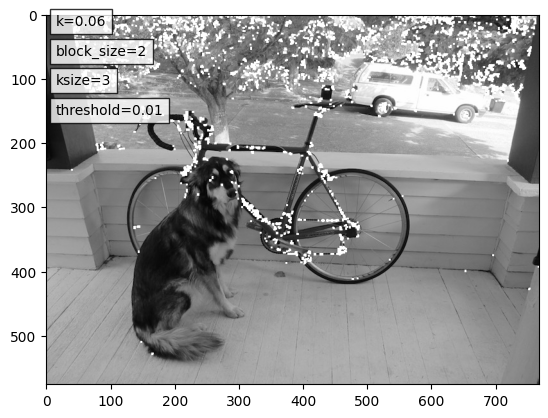

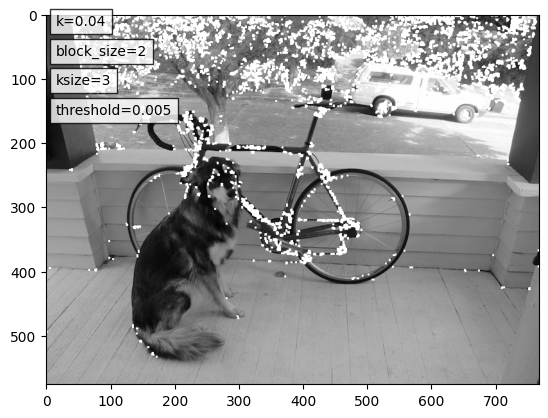

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def harris_corner_detector(img_path, block_size=2, ksize=3, k=0.06, threshold=0.01):
    img = cv2.imread(img_path, 0)
    corners = cv2.cornerHarris(src=img, blockSize=block_size, ksize=ksize, k=k)

    corners_dilated = cv2.dilate(corners, None)

    img[corners_dilated > threshold * corners_dilated.max()] = [255]

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    params = {"k": k, "block_size": block_size, "ksize": ksize, "threshold": threshold}

    for i, (param_name, value) in enumerate(params.items()):
        plt.text(
            0.02,
            1 - (i) * 0.08,
            f"{param_name}={value}",
            transform=plt.gca().transAxes,
            bbox=dict(facecolor="white", alpha=0.8),
            verticalalignment="top",
        )
    plt.show()


# for more corners:
# - decrease k
# - decrease threshold
# - decrease block_size

# for less corners:
# - increase k
# - increase threshold
# - increase block_size
harris_corner_detector("images/dog.jpg")
harris_corner_detector("images/dog.jpg", k=0.04, threshold=0.005)

## Function 2: Histogram of Oriented Gradients

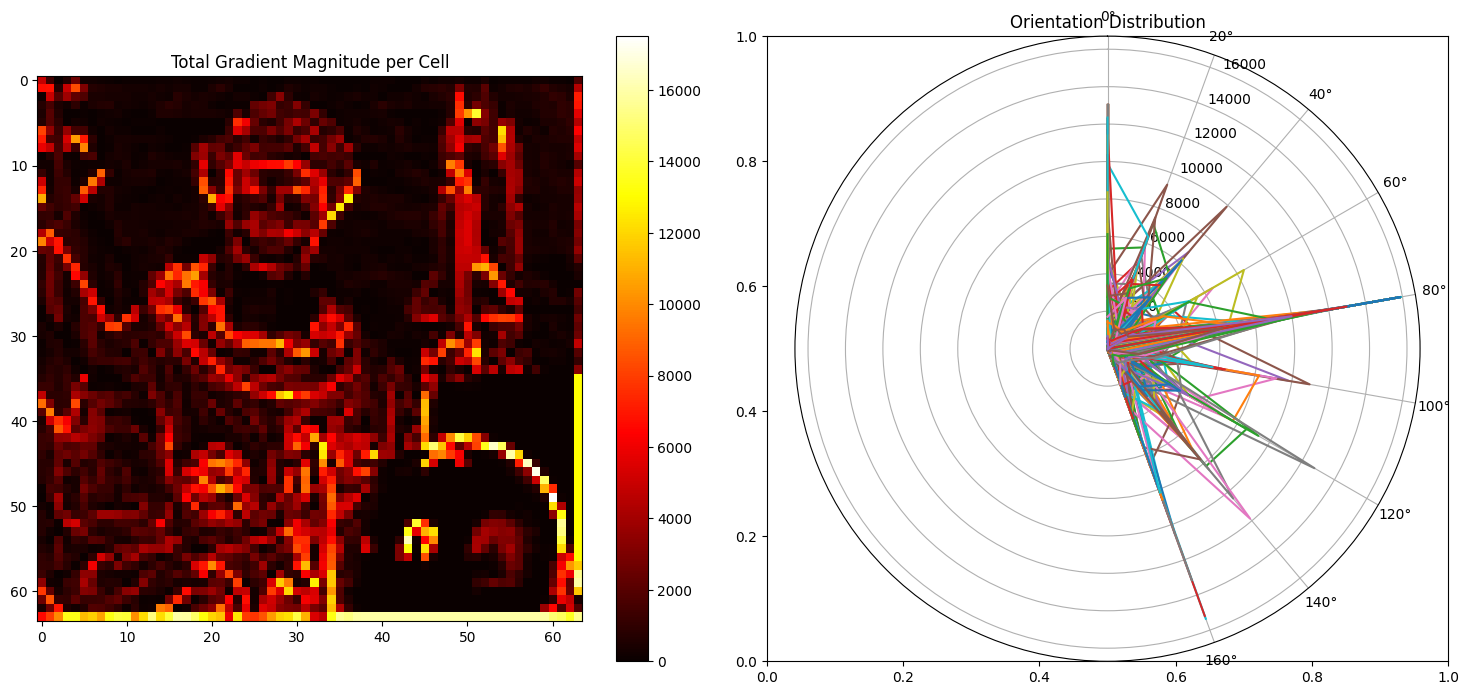

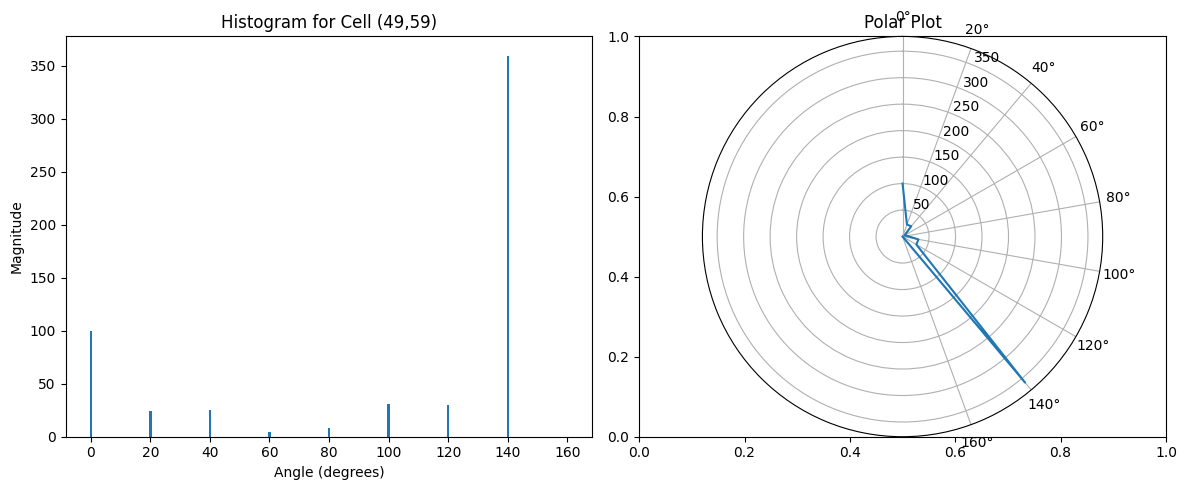

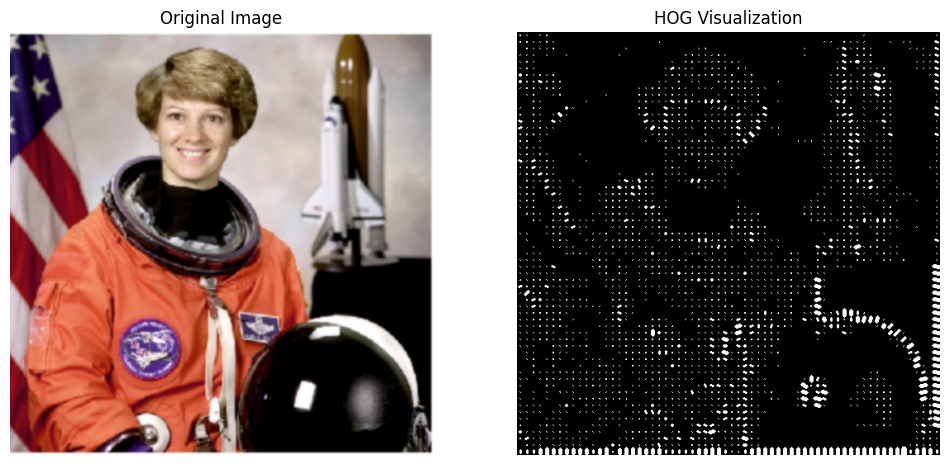

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def visualize_hog_cells(hog_cells):
    # Get dimensions
    cell_y, cell_x, bin_size = hog_cells.shape

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

    # 1. Heatmap of total gradient magnitude per cell
    total_magnitude = np.sum(hog_cells, axis=2)
    im1 = ax1.imshow(total_magnitude, cmap="hot")
    ax1.set_title("Total Gradient Magnitude per Cell")
    plt.colorbar(im1, ax=ax1)

    # 2. Visualization of orientation distribution
    # Create a polar subplot
    ax2 = plt.subplot(122, projection="polar")

    # Plot histograms for each cell
    for i in range(cell_y):
        for j in range(cell_x):
            # Get histogram for this cell
            cell_hist = hog_cells[i, j, :]

            # Calculate angles for each bin
            angles = np.linspace(0, 180, bin_size, endpoint=False)
            angles_rad = np.deg2rad(angles)

            # Plot the histogram
            ax2.plot(angles_rad, cell_hist, label=f"Cell ({i},{j})")

    ax2.set_title("Orientation Distribution")
    ax2.set_theta_zero_location("N")
    ax2.set_theta_direction(-1)
    ax2.set_thetagrids(np.arange(0, 180, 20))

    plt.tight_layout()
    plt.show()


def visualize_single_cell(hog_cells, cell_i, cell_j):
    # Get the histogram for the specified cell
    cell_hist = hog_cells[cell_i, cell_j, :]

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Bar plot of the histogram
    angles = np.linspace(0, 180, len(cell_hist), endpoint=False)
    ax1.bar(angles, cell_hist)
    ax1.set_title(f"Histogram for Cell ({cell_i},{cell_j})")
    ax1.set_xlabel("Angle (degrees)")
    ax1.set_ylabel("Magnitude")

    # 2. Polar plot
    ax2 = plt.subplot(122, projection="polar")
    angles_rad = np.deg2rad(angles)
    ax2.plot(angles_rad, cell_hist)
    ax2.set_title("Polar Plot")
    ax2.set_theta_zero_location("N")
    ax2.set_theta_direction(-1)
    ax2.set_thetagrids(np.arange(0, 180, 20))

    plt.tight_layout()
    plt.show()


def hog_visualize(img, cell_size=8, bin_size=9):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Calculate gradients (Sobel)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

    # Quantize angles into bins
    bin_width = 180 // bin_size
    bins = (angle // bin_width).astype(int)
    bins[bins == bin_size] = 0  # make 180 degree falls to bin 0

    h, w = gray.shape
    cell_x = w // cell_size
    cell_y = h // cell_size

    # Compute histogram for each cell
    hog_cells = np.zeros((cell_y, cell_x, bin_size))
    for i in range(cell_y):
        for j in range(cell_x):
            mag_cell = magnitude[
                i * cell_size : (i + 1) * cell_size, j * cell_size : (j + 1) * cell_size
            ]
            bin_cell = bins[
                i * cell_size : (i + 1) * cell_size, j * cell_size : (j + 1) * cell_size
            ]

            for b in range(bin_size):
                hog_cells[i, j, b] = np.sum(mag_cell[bin_cell == b])

    visualize_hog_cells(hog_cells)
    visualize_single_cell(hog_cells, 49, 59)

    # Visualization
    hog_image = np.zeros((h, w), dtype=np.float32)
    max_mag = hog_cells.max()

    for i in range(cell_y):
        for j in range(cell_x):
            cell_center_x = j * cell_size + cell_size // 2
            cell_center_y = i * cell_size + cell_size // 2

            for b in range(bin_size):
                if hog_cells[i, j, b] > max_mag * 0.02:
                    angle_deg = b * bin_width + bin_width / 2
                    angle_rad = np.deg2rad(angle_deg)

                    # length proportional to histogram magnitude
                    length = hog_cells[i, j, b] / max_mag * (cell_size // 2)

                    x1 = int(cell_center_x - length * np.cos(angle_rad))
                    y1 = int(cell_center_y - length * np.sin(angle_rad))
                    x2 = int(cell_center_x + length * np.cos(angle_rad))
                    y2 = int(cell_center_y + length * np.sin(angle_rad))
                    thickness = int((hog_cells[i, j, b] / max_mag) * 4) + 1

                    cv2.line(
                        hog_image, (x1, y1), (x2, y2), color=255, thickness=thickness
                    )

    return hog_image


# Load and resize image
img = cv2.imread("./images/astronaut.png")
img = cv2.resize(img, (512, 512))  # Typical HOG window size

hog_vis = hog_visualize(img)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.axis("off")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("HOG Visualization")
plt.axis("off")
plt.imshow(hog_vis, cmap="gray")

plt.show()

## Function 3: Canny Operator

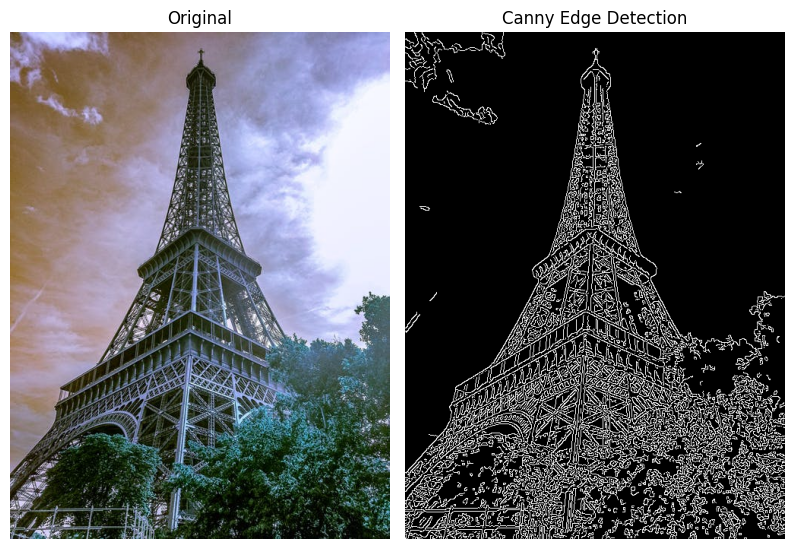

In [3]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("./images/eiffel.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(img, (3, 3), 0)

edges = cv2.Canny(blur, 75, 150)

# Show using matplotlib
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")


plt.subplot(1, 3, 2)
plt.title("Canny Edge Detection")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

## Function 4 : Hough Transform
Here, we will use data from the previous exercise

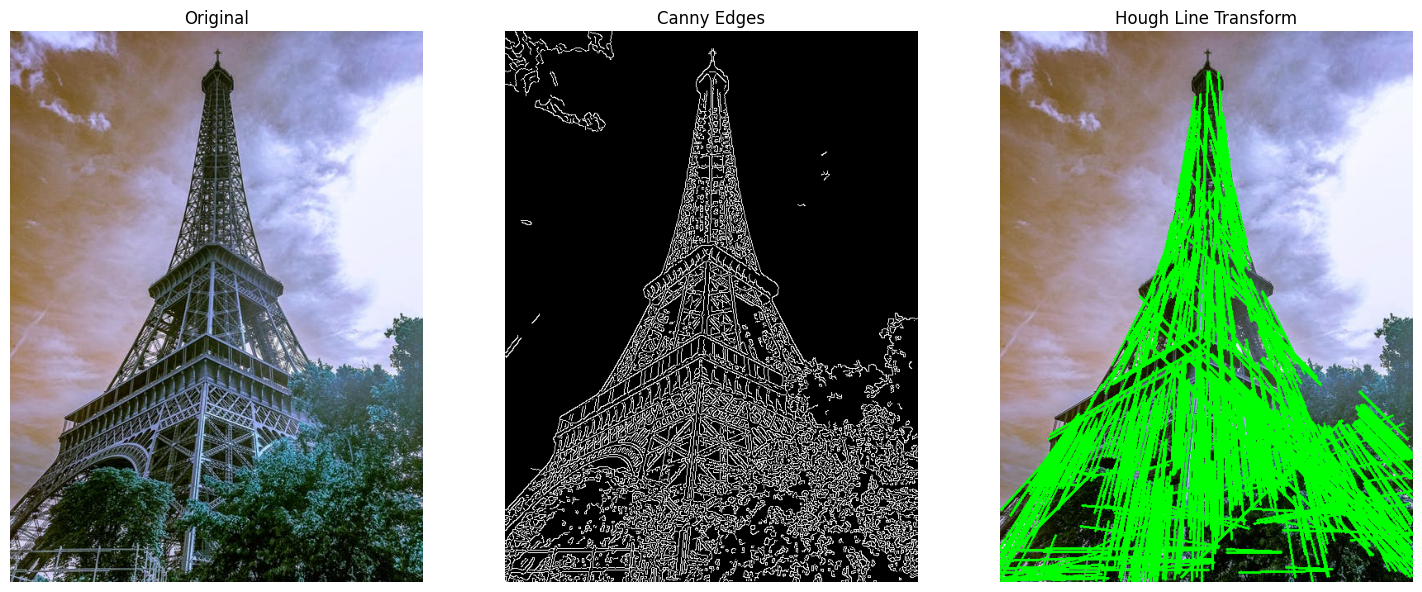

In [4]:
lines = cv2.HoughLinesP(
    edges,
    rho=1,  # distance resolution in pixels
    theta=np.pi / 180,  # angle resolution in radians
    threshold=100,  # minimum number of votes
    minLineLength=50,  # minimum length of line
    maxLineGap=10,
)

line_img = img.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)


plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Canny Edges")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Hough Line Transform")
plt.imshow(line_img)
plt.axis("off")

plt.tight_layout()
plt.show()